In [27]:
from dotenv import load_dotenv

load_dotenv()

True

In [28]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [29]:
from langchain_core.tools import tool

@tool
def add(a: int, b: int) -> int:
    """숫자 a와 b를 더한 결과를 반환합니다."""
    return a + b

@tool
def multiply(a: int, b: int) -> int:
    """숫자 a와 b를 곱한 결과를 반환합니다."""
    return a * b

In [30]:
from langgraph.prebuilt import ToolNode

tool_list = [add, multiply]
llm_with_tools = llm.bind_tools(tool_list)
tool_node = ToolNode(tool_list)

In [31]:
ai_message = llm_with_tools.invoke('What is 3 plus 5?')

In [32]:
from langgraph.runtime import Runtime

# ToolNode는 그래프 밖에서 단독 호출할 때 Runtime을 넘겨야 합니다.
tool_node.invoke({'messages': [ai_message]}, runtime=Runtime())

{'messages': [ToolMessage(content='8', name='add', tool_call_id='51f9ade8-719b-4e12-832c-e479a1a6f090')]}

In [33]:
from langgraph.graph import MessagesState, StateGraph

graph_builder = StateGraph(MessagesState)

In [34]:
def agent(state: MessagesState):
    messages = state['messages']
    response = llm_with_tools.invoke(messages)
    return {'messages': [response]}

In [ ]:
from langgraph.graph import END

def should_continue(state: MessagesState):
    messages = state['messages']
    last_message = messages[-1]
    if last_message.tool_calls:
        return 'tools'
    return END

In [36]:
graph_builder.add_node('agent', agent)
graph_builder.add_node('tools', tool_node)

In [37]:
from langgraph.graph import START, END

graph_builder.add_edge(START, 'agent')
graph_builder.add_conditional_edges(
    'agent',
    should_continue,
    ['tools', END]
)
graph_builder.add_edge('tools', 'agent')

graph = graph_builder.compile()

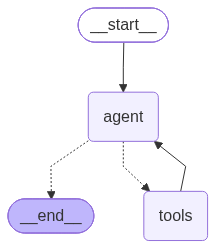

In [38]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [39]:
from langchain_core.messages import HumanMessage

for chunk in graph.stream({'messages': [HumanMessage(content='3에다 5를 더하고 거기다 8을 곱하면?')]}, stream_mode='values'):
    chunk['messages'][-1].pretty_print()


================================ Human Message =================================

3에다 5를 더하고 거기다 8을 곱하면?
================================== Ai Message ==================================
Tool Calls:
  add (36d95906-3010-4368-9334-a3b6c40bf275)
 Call ID: 36d95906-3010-4368-9334-a3b6c40bf275
  Args:
    a: 3
    b: 5
================================= Tool Message =================================
Name: add

8
================================== Ai Message ==================================
Tool Calls:
  multiply (600b45f6-0fc4-46c3-b42a-dece672f323b)
 Call ID: 600b45f6-0fc4-46c3-b42a-dece672f323b
  Args:
    b: 8
    a: 8
================================= Tool Message =================================
Name: multiply

64
================================== Ai Message ==================================

[{'type': 'text', 'text': '3에다 5를 더하고 거기다 8을 곱하면 64입니다.', 'extras': {'signature': 'CooCARFNMg/53PEv6S2juFQq1tEdOhYSpaILq+0h8k/O5V6oIvZOFvJyaDy/7QOKn+UzcnSiLOf7UpnkKMIdESWvjOpMQtxPC+KD5znvT4lAU